### Chronic Kidney Disease EDA

#### Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default plot style and show all dataframe columns.
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Load Dataset

In [2]:
# Load the CKD dataset and define the target column used in the analysis.
datasetPath = "dataset/chronic-kidney-disease.csv"
targetColumn = "ckdDiagnosis"

ckdData = pd.read_csv(datasetPath)

ckdData.head()

,patientId,age,gender,bmi,systolicBp,diastolicBp,serumCreatinine,egfr,bloodUrea,hemoglobin,urineProtein,urineSpecificGravity,bloodGlucose,diabetesMellitus,hypertension,smokingStatus,familyHistoryCkd,anemia,pedalEdema,ckdDiagnosis
0,1,62,Female,28.6,140,84,1.61,76.9,12.4,14.5,2,1.011,96.7,No,Yes,Former,No,No,No,No CKD
1,2,41,Female,34.6,105,78,1.41,58.5,30.6,12.3,2,1.011,121.7,No,No,Never,Yes,Yes,No,CKD
2,3,68,Female,26.4,115,80,2.35,66.4,7.0,12.8,2,1.019,75.8,No,No,Never,Yes,Yes,No,CKD
3,4,71,Male,25.5,132,79,2.55,104.9,44.2,12.4,3,1.006,105.8,No,No,Never,No,Yes,No,CKD
4,5,28,Female,29.9,130,55,0.82,96.1,7.0,14.0,1,1.023,65.0,No,No,Never,No,No,No,No CKD


Dataset Overview

In [3]:
# Separate numerical and categorical columns for quick dataset profiling.
numericalColumns = ckdData.select_dtypes(include=np.number).columns.tolist()
categoricalColumns = ckdData.select_dtypes(exclude=np.number).columns.tolist()

datasetOverview = pd.DataFrame({
    "metric": [
        "total rows",
        "total columns",
        "numerical columns count",
        "categorical columns count",
        "target variable name"
    ],
    "value": [
        ckdData.shape[0],
        ckdData.shape[1],
        len(numericalColumns),
        len(categoricalColumns),
        targetColumn
    ]
})

datasetOverview

,metric,value
0,total rows,46450
1,total columns,20
2,numerical columns count,12
3,categorical columns count,8
4,target variable name,ckdDiagnosis


In [4]:
# List each column with its detected data type.
columnSummary = pd.DataFrame({
    "columnName": ckdData.columns,
    "dataType": ckdData.dtypes.astype(str).values,
})

columnSummary

,columnName,dataType
0,patientId,int64
1,age,int64
2,gender,object
3,bmi,float64
4,systolicBp,int64
5,diastolicBp,int64
6,serumCreatinine,float64
7,egfr,float64
8,bloodUrea,float64
9,hemoglobin,float64


Data Quality Assessment: Checks missing values and duplicate rows

In [5]:
# Count missing values and duplicate rows before deeper analysis.
totalMissingValues = int(ckdData.isnull().sum().sum())
duplicateRows = int(ckdData.duplicated().sum())
duplicatePercentage = round((duplicateRows / len(ckdData)) * 100, 2)

dataQualitySummary = pd.DataFrame({
    "metric": ["total missing values", "duplicate rows"],
    "value": [totalMissingValues, duplicateRows]
})

dataQualitySummary

,metric,value
0,total missing values,0
1,duplicate rows,0


Target Variable Distribution: Checks the CKD and No CKD class balance

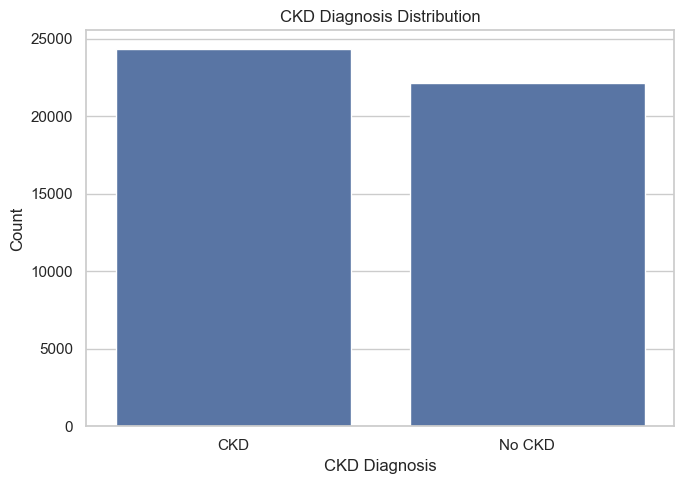

,ckdDiagnosis,frequency
0,CKD,24314
1,No CKD,22136


In [6]:
# Calculate and plot the class balance for the CKD diagnosis target.
targetFrequency = (
    ckdData[targetColumn]
    .value_counts(dropna=False)
    .rename_axis(targetColumn)
    .reset_index(name="frequency")
)

plt.figure(figsize=(7, 5))
sns.countplot(data=ckdData, x=targetColumn, order=targetFrequency[targetColumn])
plt.title("CKD Diagnosis Distribution")
plt.xlabel("CKD Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

targetFrequency

Numerical Feature Distribution

In [7]:
# Keep only expected columns that are present in the dataset.
def getExistingColumns(columnList, dataFrame):
    return [columnName for columnName in columnList if columnName in dataFrame.columns]

importantNumericalColumns = [
    "age",
    "bmi",
    "systolicBp",
    "diastolicBp",
    "serumCreatinine",
    "egfr",
    "bloodUrea",
    "hemoglobin",
    "urineProtein",
    "urineSpecificGravity",
    "bloodGlucose"
]

selectedNumericalColumns = getExistingColumns(importantNumericalColumns, ckdData)

# Summarize key numerical features with basic descriptive statistics.
numericalSummary = ckdData[selectedNumericalColumns].describe().T

numericalSummary

,count,mean,std,min,25%,50%,75%,max
age,46450.0,57.000022,14.591401,24.000,47.000,57.000,67.00,88.00
bmi,46450.0,27.575772,5.456899,16.000,23.800,27.500,31.30,45.00
systolicBp,46450.0,125.092637,19.018292,90.000,111.000,124.000,138.00,190.00
diastolicBp,46450.0,76.322260,10.771404,55.000,69.000,76.000,84.00,117.00
serumCreatinine,46450.0,1.834611,1.064986,0.550,1.140,1.610,2.26,7.20
egfr,46450.0,75.022344,25.580750,8.000,57.200,75.500,93.80,120.00
bloodUrea,46450.0,27.363242,19.006385,7.000,12.300,21.500,39.10,105.00
hemoglobin,46450.0,13.168284,1.838442,7.500,11.900,13.400,14.50,17.50
urineProtein,46450.0,1.279397,1.148194,0.000,0.000,1.000,2.00,4.00
urineSpecificGravity,46450.0,1.016335,0.005058,1.005,1.013,1.016,1.02,1.03


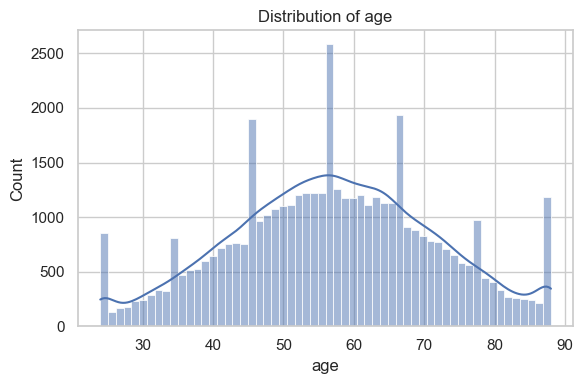

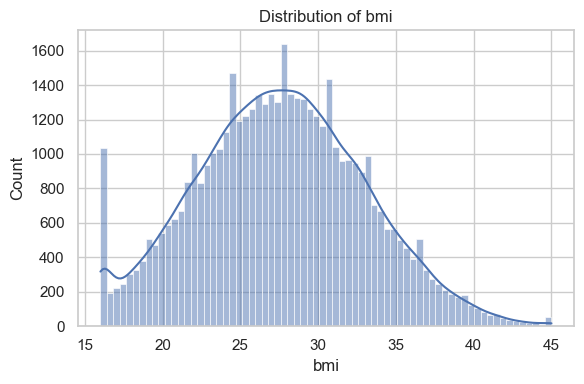

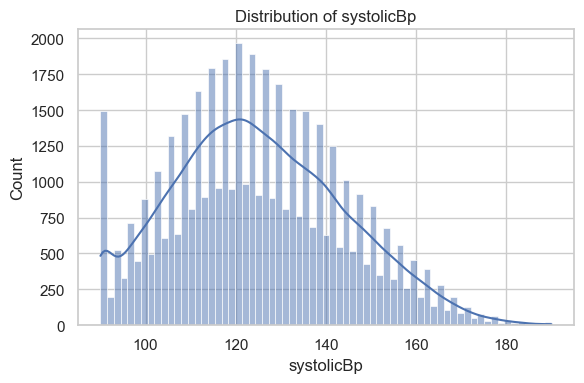

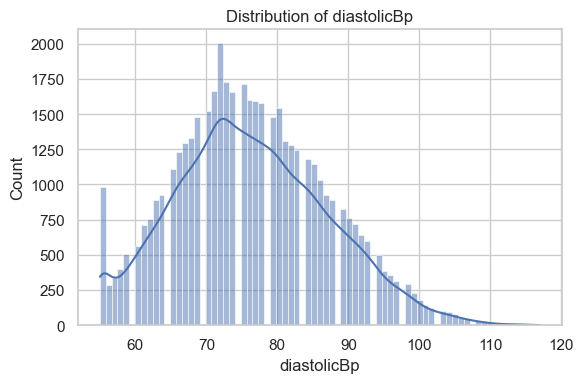

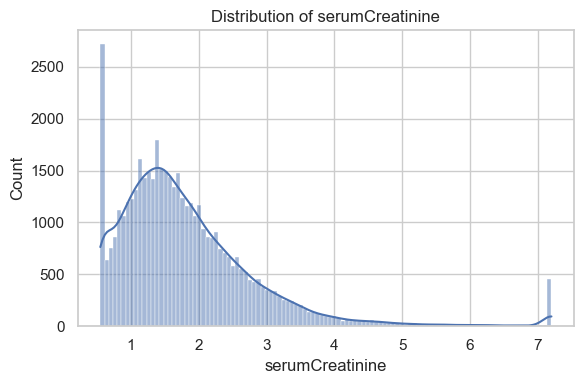

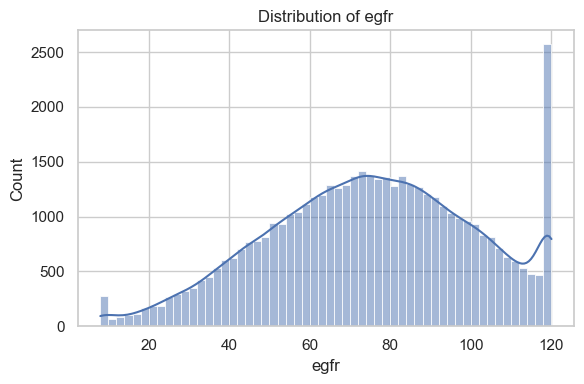

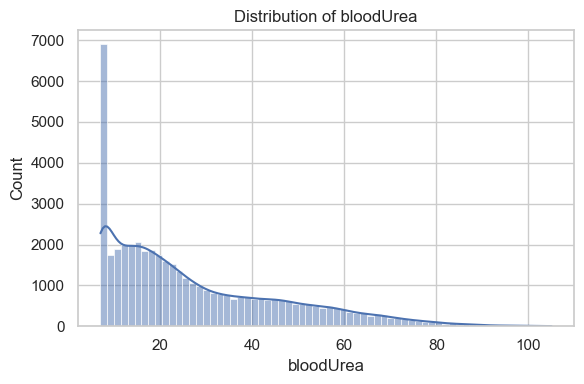

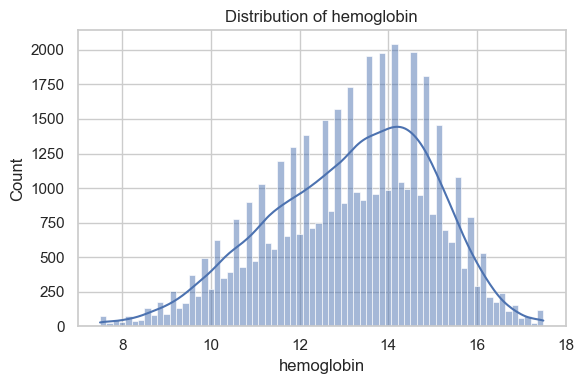

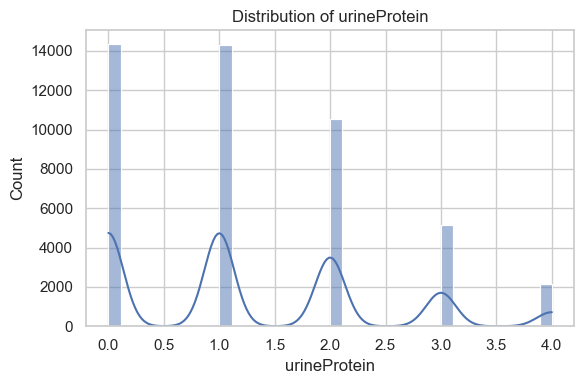

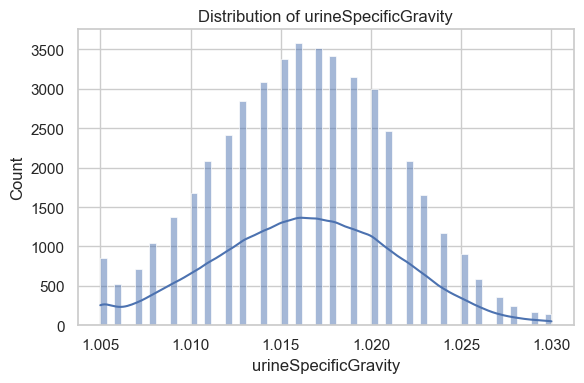

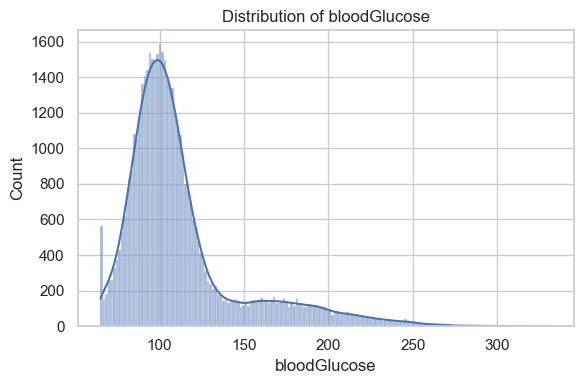

In [8]:
# Plot each numerical feature to inspect shape, spread, and outliers.
if selectedNumericalColumns:
    for columnName in selectedNumericalColumns:

        plt.figure(figsize=(6, 4))
        sns.histplot(data=ckdData, x=columnName, kde=True)
        plt.title(f"Distribution of {columnName}")
        plt.xlabel(columnName)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

Categorical Feature Distribution

In [9]:
# Select important categorical variables and display their frequencies.
importantCategoricalColumns = [
    "gender",
    "diabetesMellitus",
    "hypertension",
    "smokingStatus",
    "familyHistoryCkd",
    "anemia",
    "pedalEdema"
]

selectedCategoricalColumns = getExistingColumns(importantCategoricalColumns, ckdData)

for columnName in selectedCategoricalColumns:
    frequencyTable = (
        ckdData[columnName]
        .value_counts(dropna=False)
        .rename_axis(columnName)
        .reset_index(name="frequency")
    )
    display(frequencyTable)

,gender,frequency
0,Female,23652
1,Male,22798


,diabetesMellitus,frequency
0,No,36378
1,Yes,10072


,hypertension,frequency
0,No,31505
1,Yes,14945


,smokingStatus,frequency
0,Never,26824
1,Former,11771
2,Current,7855


,familyHistoryCkd,frequency
0,No,40590
1,Yes,5860


,anemia,frequency
0,No,29004
1,Yes,17446


,pedalEdema,frequency
0,No,39652
1,Yes,6798


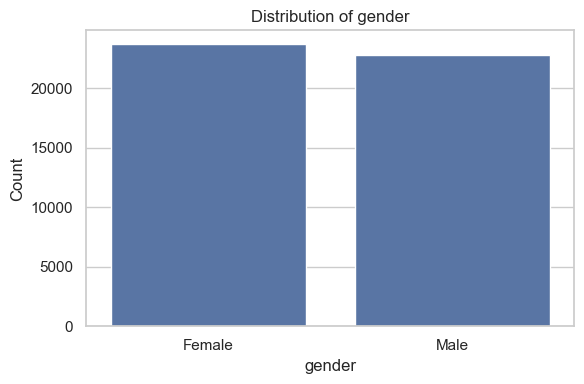

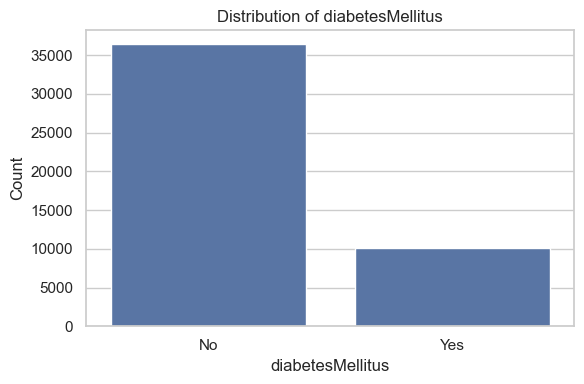

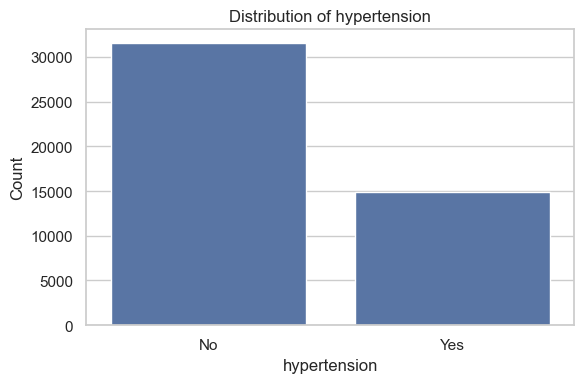

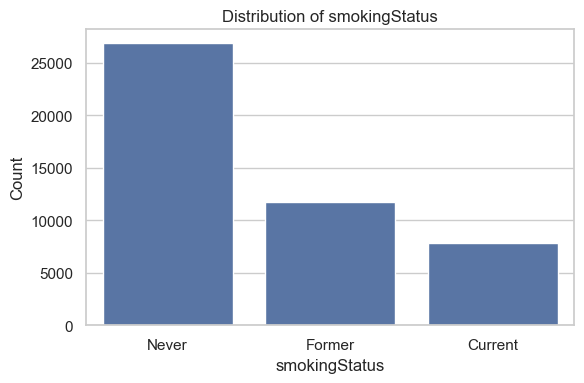

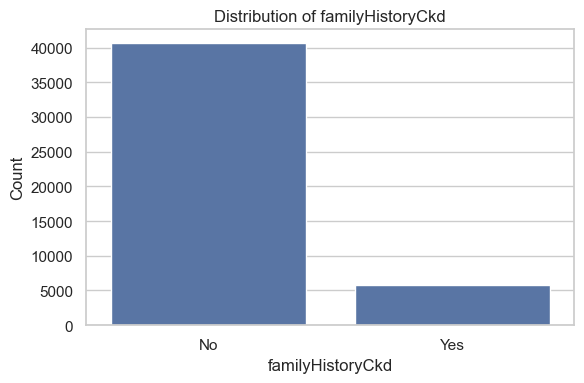

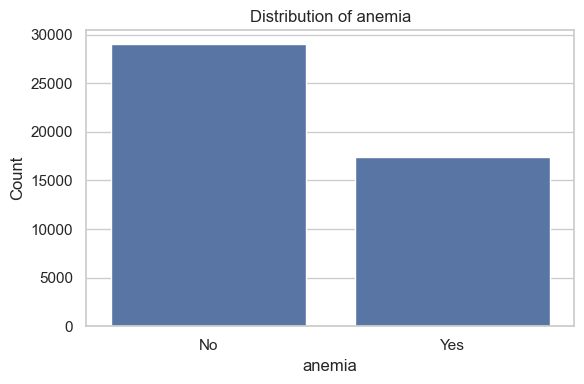

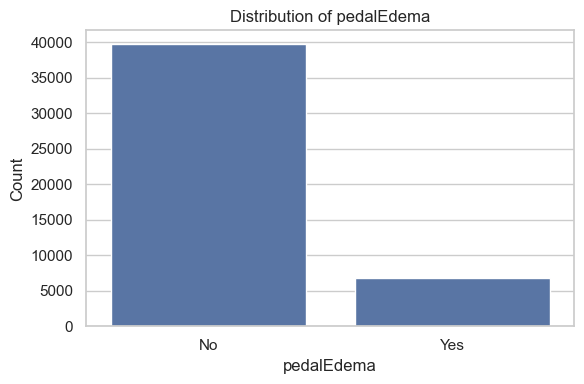

In [10]:
# Plot category counts for each selected categorical feature.
if selectedCategoricalColumns:
    for columnName in selectedCategoricalColumns:

        plt.figure(figsize=(6, 4))
        valueOrder = ckdData[columnName].value_counts(dropna=False).index
        sns.countplot(data=ckdData, x=columnName, order=valueOrder)
        plt.title(f"Distribution of {columnName}")
        plt.xlabel(columnName)
        plt.ylabel("Count")
        plt.xticks()  
        plt.tight_layout()
        plt.show()


CKD vs Numerical Features

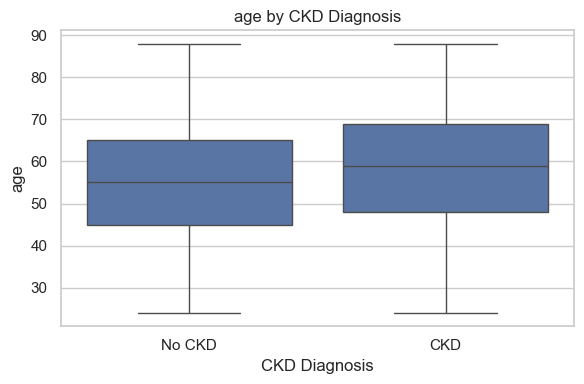

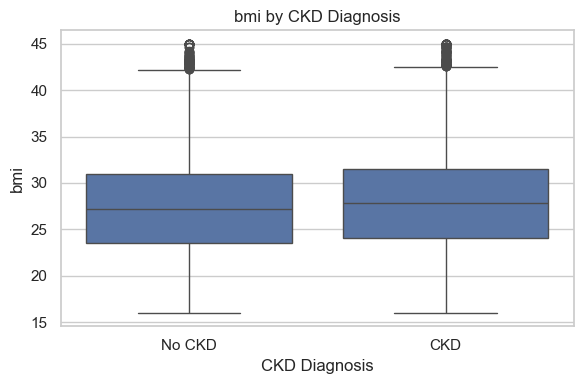

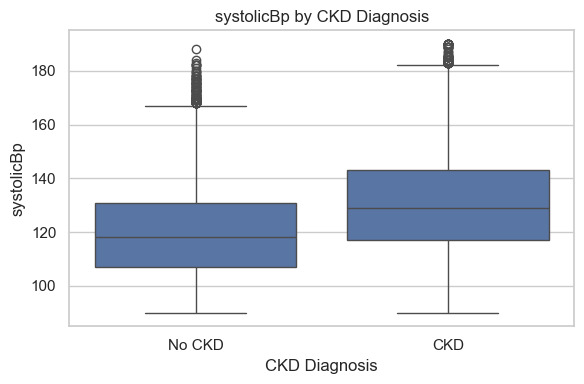

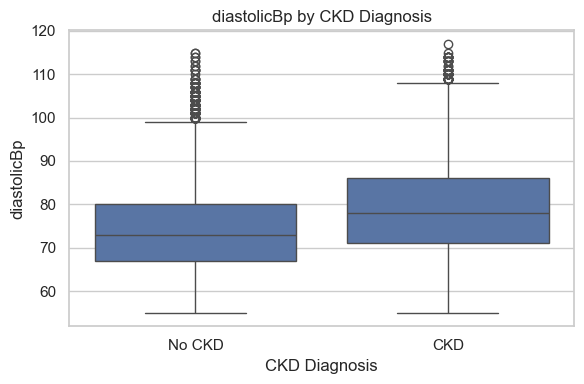

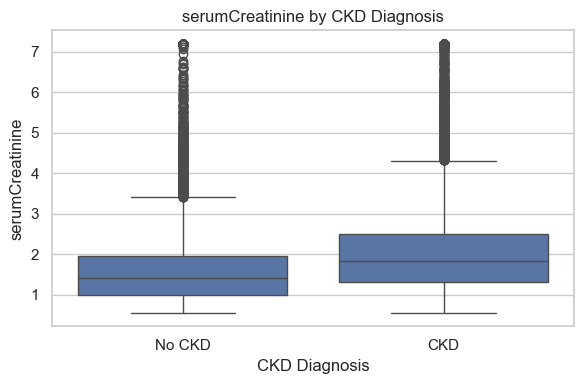

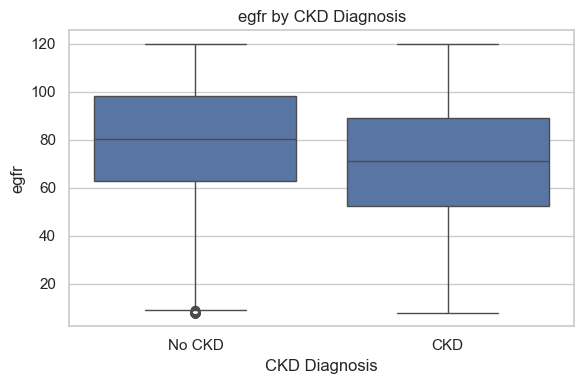

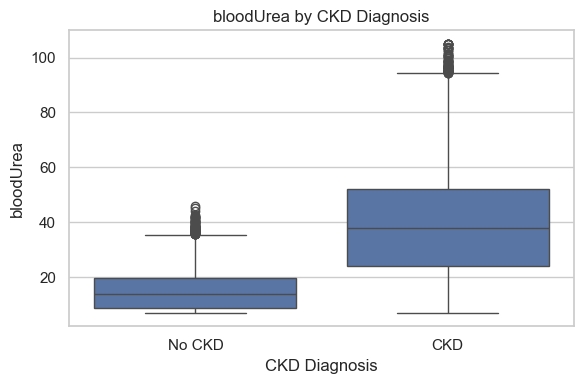

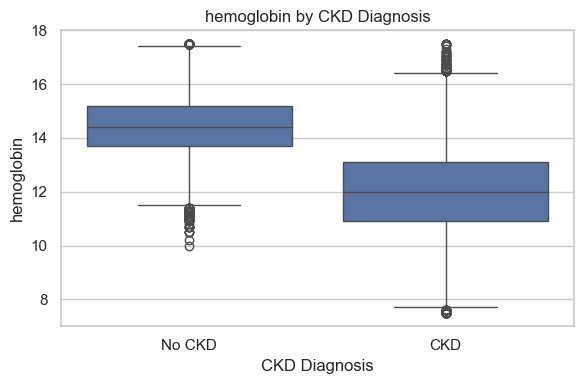

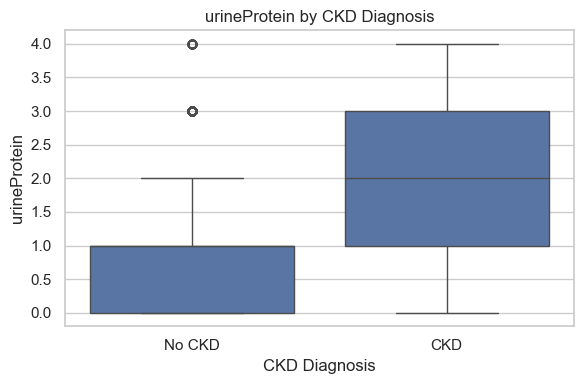

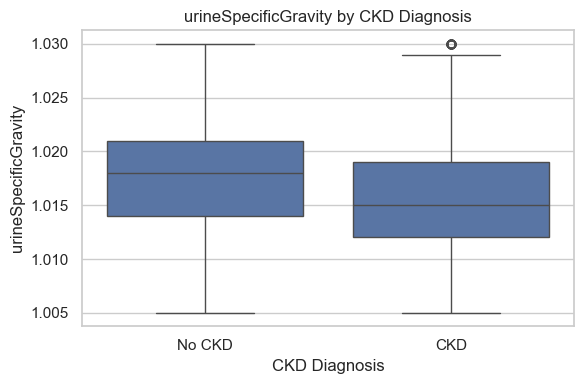

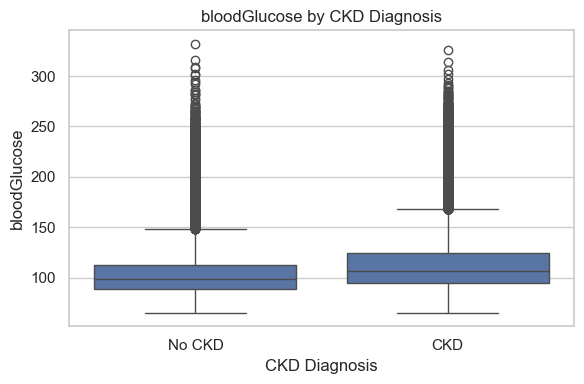

In [11]:
# Compare clinical numerical features across CKD diagnosis groups.
clinicalComparisonColumns = [
    "age",
    "bmi",
    "systolicBp",
    "diastolicBp",
    "serumCreatinine",
    "egfr",
    "bloodUrea",
    "hemoglobin",
    "urineProtein",
    "urineSpecificGravity",
    "bloodGlucose"
]

selectedClinicalColumns = getExistingColumns(clinicalComparisonColumns, ckdData)

if selectedClinicalColumns:
    for columnName in selectedClinicalColumns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(data=ckdData, x=targetColumn, y=columnName)
        plt.title(f"{columnName} by CKD Diagnosis")
        plt.xlabel("CKD Diagnosis")
        plt.ylabel(columnName)
        plt.tight_layout()
        plt.show()


CKD vs Categorical Features

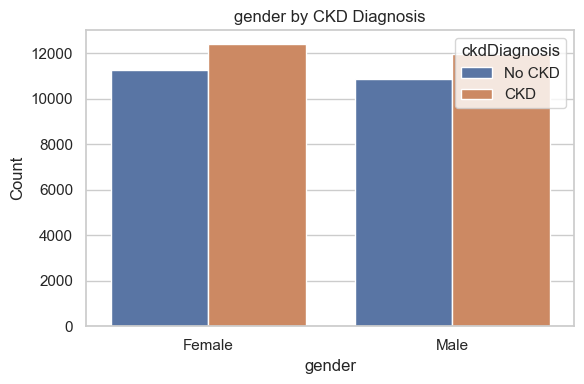

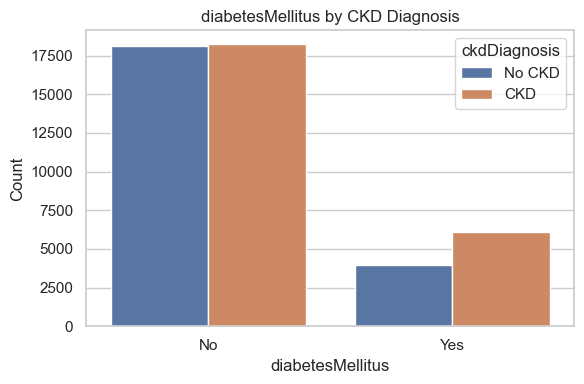

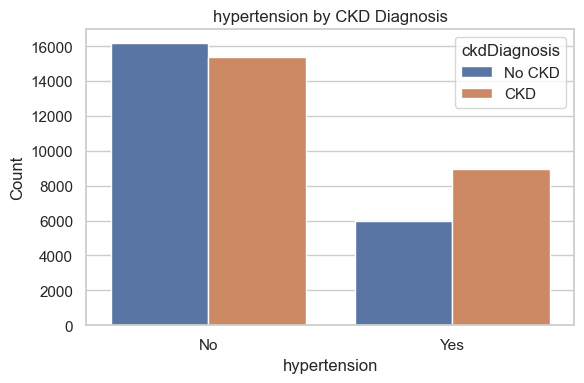

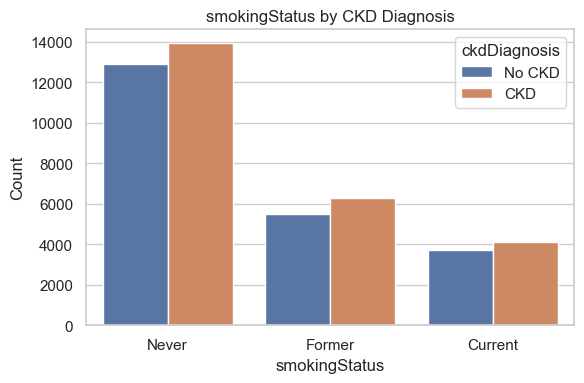

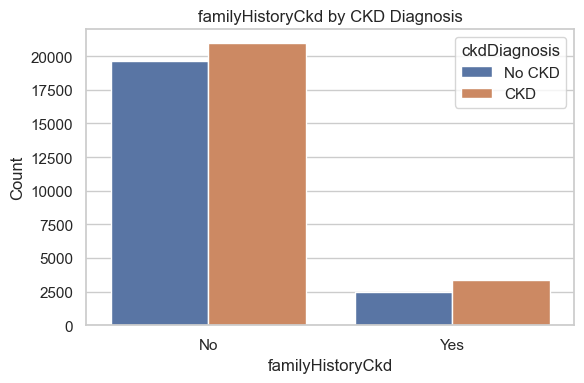

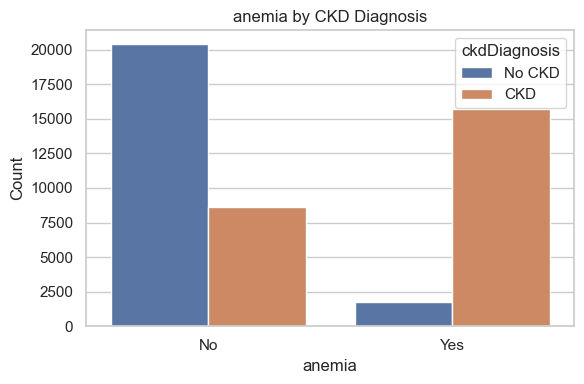

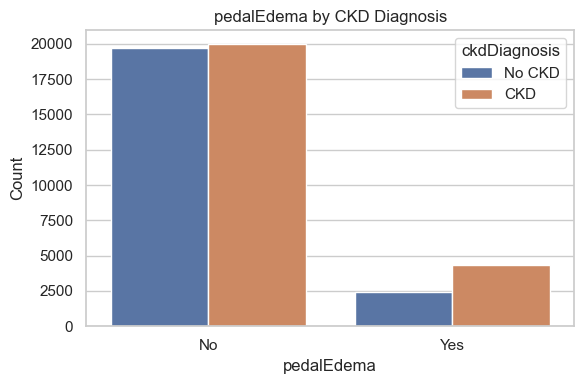

In [12]:
# Compare risk factor categories against the CKD diagnosis target.
riskFactorColumns = [
    "gender",
    "diabetesMellitus",
    "hypertension",
    "smokingStatus",
    "familyHistoryCkd",
    "anemia",
    "pedalEdema"
]

selectedRiskFactorColumns = getExistingColumns(riskFactorColumns, ckdData)

if selectedRiskFactorColumns:
    for columnName in selectedRiskFactorColumns:
        plt.figure(figsize=(6, 4))
        valueOrder = ckdData[columnName].value_counts(dropna=False).index
        sns.countplot(
            data=ckdData,
            x=columnName,
            hue=targetColumn,
            order=valueOrder
        )
        plt.title(f"{columnName} by CKD Diagnosis")
        plt.xlabel(columnName)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()


Correlation Analysis

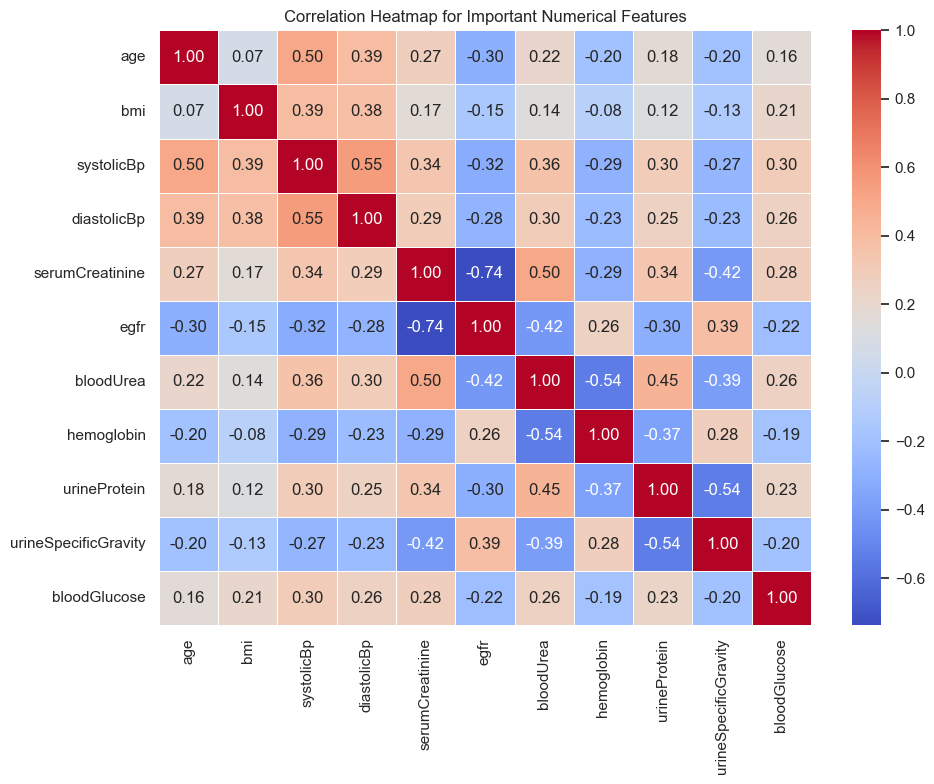

In [13]:
# Build a correlation matrix for the selected numerical features.
numericFeatureColumns = ckdData.select_dtypes(include=np.number).columns.tolist()
correlationColumns = [
    columnName for columnName in importantNumericalColumns
    if columnName in numericFeatureColumns
]

if correlationColumns:
    correlationMatrix = ckdData[correlationColumns].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlationMatrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap for Important Numerical Features")
    plt.tight_layout()
    plt.show()